<a href="https://colab.research.google.com/github/m7moudkaram/Employee-Churn-ANN/blob/main/Employee-Churn-ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Churn Prediction using ANN

**Dataset:** HR Analytics Case Study (Kaggle)  
**Author:** Greenland Team | Faculty of Artificial Intelligence, Kafrelsheikh University  
**Platform:** Google Colab  

---

> **How to use:** Set your GitHub username and repo name in **Section 0**, then run all cells via `Runtime > Run all`. No file upload needed.

In [7]:
# ================================================================
# Dataset loaded directly from GitHub — no upload needed
# ================================================================
BASE_URL = "https://raw.githubusercontent.com/m7moudkaram/Employee-Churn-ANN/main/Data/"

# ==================================================================
# Import libraries (all pre-installed in Google Colab)
# ==================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('All libraries imported successfully.')
print(f'TensorFlow version : {tf.__version__}')
print(f'Pandas version     : {pd.__version__}')

All libraries imported successfully.
TensorFlow version : 2.20.0
Pandas version     : 2.2.2


## Section 1 — Load & Merge Datasets
> All three files share the `EmployeeID` column. We use an **inner join** to keep only employees present in all three files.

In [8]:
# Load all 3 CSV files directly from GitHub — no upload needed
general_df         = pd.read_csv(BASE_URL + 'general_data.csv')
employee_survey_df = pd.read_csv(BASE_URL + 'employee_survey_data.csv')
manager_survey_df  = pd.read_csv(BASE_URL + 'manager_survey_data.csv')

print('Dataset loaded successfully from GitHub.')
print(f'  general_data        : {general_df.shape}')
print(f'  employee_survey     : {employee_survey_df.shape}')
print(f'  manager_survey      : {manager_survey_df.shape}')

Dataset loaded successfully from GitHub.
  general_data        : (4410, 24)
  employee_survey     : (4410, 4)
  manager_survey      : (4410, 3)


## Section 2 — Exploratory Data Analysis (EDA)

### 2.1 — Basic Overview

In [9]:
df = pd.merge(general_df, employee_survey_df, on='EmployeeID', how='inner')
df = pd.merge(df, manager_survey_df, on='EmployeeID', how='inner')

print("\u2500\u2500 First 5 rows \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
df.head()

── First 5 rows ───────────────────────────────────


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,6,1,0,0,3.0,4.0,2.0,3,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,6.0,3,5,1,4,3.0,2.0,4.0,2,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,5.0,2,5,0,3,2.0,2.0,1.0,3,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,13.0,5,8,7,5,4.0,4.0,3.0,2,3
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,9.0,2,6,0,4,4.0,1.0,3.0,3,3


In [10]:
print("\u2500\u2500 Data types & non-null counts \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
df.info()
print("\n\u2500\u2500 Statistical summary \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
df.describe()

── Data types & non-null counts ────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,...,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
count,4410.000000,4410.000000,4410.000000,4410.0,4410.000000,4410.000000,4410.000000,4391.000000,4410.000000,4410.0,...,4401.000000,4410.000000,4410.000000,4410.000000,4410.000000,4385.000000,4390.000000,4372.000000,4410.000000,4410.000000
mean,36.923810,9.192517,2.912925,1.0,2205.500000,2.063946,65029.312925,2.694830,15.209524,8.0,...,11.279936,2.799320,7.008163,2.187755,4.123129,2.723603,2.728246,2.761436,2.729932,3.153741
std,9.133301,8.105026,1.023933,0.0,1273.201673,1.106689,47068.888559,2.498887,3.659108,0.0,...,7.782222,1.288978,6.125135,3.221699,3.567327,1.092756,1.101253,0.706245,0.711400,0.360742
min,18.000000,1.000000,1.000000,1.0,1.000000,1.000000,10090.000000,0.000000,11.000000,8.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,3.000000
25%,30.000000,2.000000,2.000000,1.0,1103.250000,1.000000,29110.000000,1.000000,12.000000,8.0,...,6.000000,2.000000,3.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
50%,36.000000,7.000000,3.000000,1.0,2205.500000,2.000000,49190.000000,2.000000,14.000000,8.0,...,10.000000,3.000000,5.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,43.000000,14.000000,4.000000,1.0,3307.750000,3.000000,83800.000000,4.000000,18.000000,8.0,...,15.000000,3.000000,9.000000,3.000000,7.000000,4.000000,4.000000,3.000000,3.000000,3.000000
max,60.000000,29.000000,5.000000,1.0,4410.000000,5.000000,199990.000000,9.000000,25.000000,8.0,...,40.000000,6.000000,40.000000,15.000000,17.000000,4.000000,4.000000,4.000000,4.000000,4.000000


### 2.2 — Missing Values

In [11]:
# Display missing value report
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_report[missing_report['Missing Count'] > 0])

# Data-verified missing columns (confirmed by inspecting the actual files):
#   NumCompaniesWorked (19), TotalWorkingYears (9)  → from general_data
#   EnvironmentSatisfaction (25), JobSatisfaction (20), WorkLifeBalance (38) → from employee_survey
# Strategy: fill all with MEDIAN — robust to skew for ordinal/numeric columns.

cols_with_missing = [
    'NumCompaniesWorked',
    'TotalWorkingYears',
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'WorkLifeBalance',
]

for col in cols_with_missing:
    if col in df.columns and df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  \u2714 '{col}' \u2192 filled with median = {median_val}")

print(f"\n\u2705 Missing values remaining: {df.isnull().sum().sum()}")

                         Missing Count  Missing %
NumCompaniesWorked                  19       0.43
TotalWorkingYears                    9       0.20
EnvironmentSatisfaction             25       0.57
JobSatisfaction                     20       0.45
WorkLifeBalance                     38       0.86
  ✔ 'NumCompaniesWorked' → filled with median = 2.0
  ✔ 'TotalWorkingYears' → filled with median = 10.0
  ✔ 'EnvironmentSatisfaction' → filled with median = 3.0
  ✔ 'JobSatisfaction' → filled with median = 3.0
  ✔ 'WorkLifeBalance' → filled with median = 3.0

✅ Missing values remaining: 0


### 2.3 — Target Variable Distribution (Attrition)

           Count  Percentage (%)
Attrition                       
No          3699           83.88
Yes          711           16.12


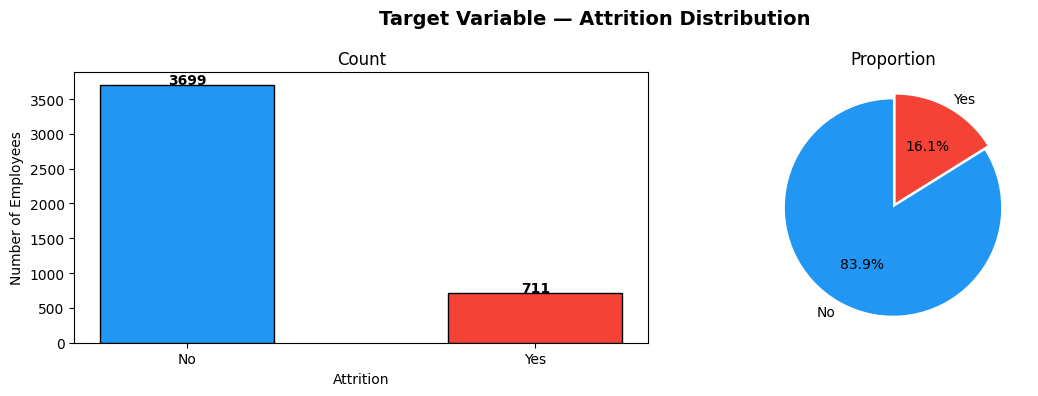

📊 Plot saved → attrition_distribution.png


In [12]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct    = df['Attrition'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': attrition_counts, 'Percentage (%)': attrition_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable — Attrition Distribution', fontsize=14, fontweight='bold')

axes[0].bar(attrition_counts.index, attrition_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
axes[0].set_title('Count')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(attrition_counts.values, labels=attrition_counts.index,
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('attrition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\U0001f4ca Plot saved \u2192 attrition_distribution.png")

### 2.4 — Correlation Heatmap

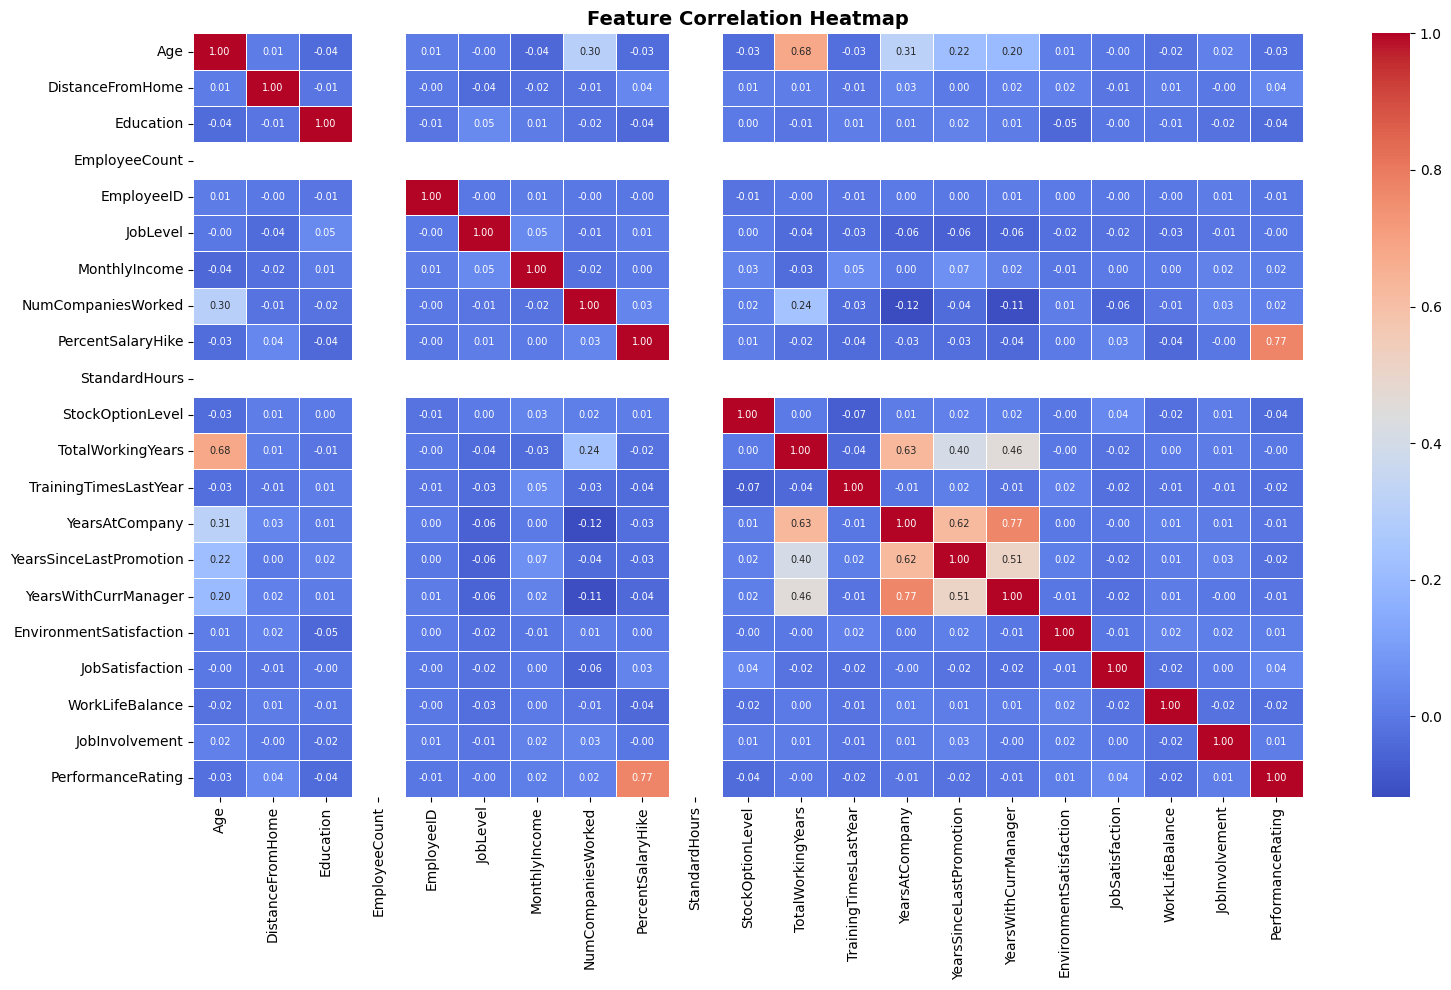

📊 Plot saved → correlation_heatmap.png


In [13]:
plt.figure(figsize=(16, 10))
numeric_df  = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\U0001f4ca Plot saved \u2192 correlation_heatmap.png")

### 2.5 — Attrition by Key Categorical Variables

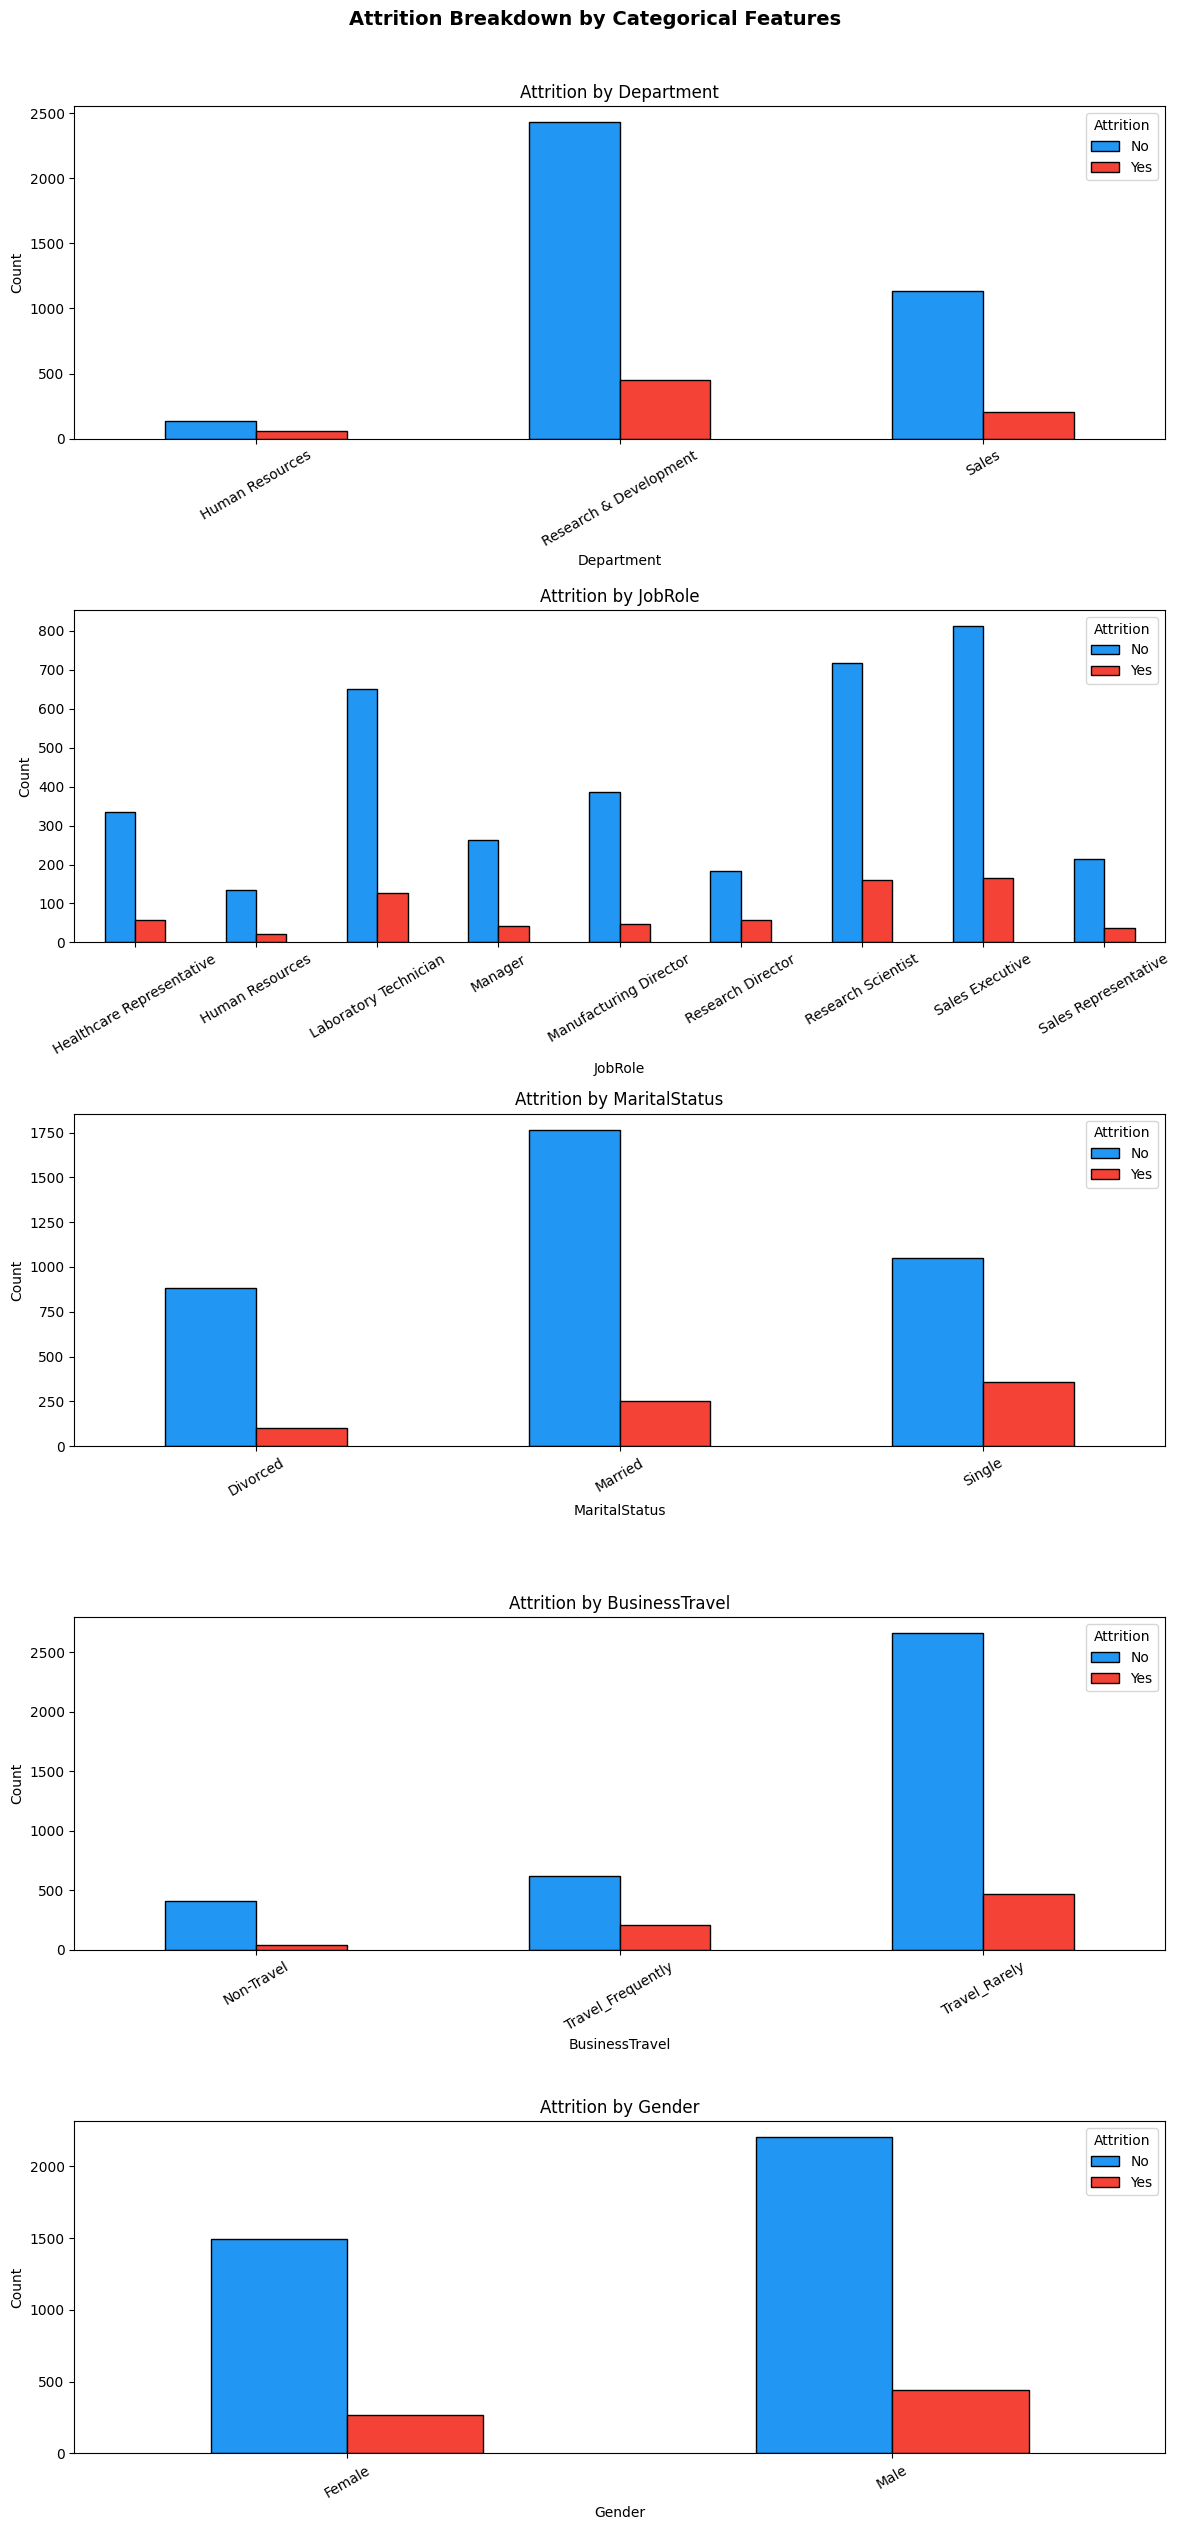

📊 Plot saved → attrition_by_categories.png


In [14]:
categorical_cols = ['Department', 'JobRole', 'MaritalStatus', 'BusinessTravel', 'Gender']
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 5 * len(categorical_cols)))
fig.suptitle('Attrition Breakdown by Categorical Features', fontsize=14, fontweight='bold', y=1.01)

for ax, col in zip(axes, categorical_cols):
    ct = df.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['#2196F3', '#F44336'], edgecolor='black')
    ax.set_title(f"Attrition by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Attrition')

plt.tight_layout()
plt.savefig('attrition_by_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("\U0001f4ca Plot saved \u2192 attrition_by_categories.png")

## Section 3 — Data Preprocessing

### 3.1 — Drop Irrelevant Columns & Encode Target

In [15]:
# Drop constant / non-informative columns
# EmployeeID → identifier only | EmployeeCount, Over18, StandardHours → constant values
cols_to_drop = ['EmployeeID', 'EmployeeCount', 'Over18', 'StandardHours']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f"\u2705 Dropped: {cols_to_drop}")
print(f"   Remaining shape : {df.shape}")

# Encode target: 'Yes' → 1 (churned) | 'No' → 0 (stayed)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(f"\n\u2705 Target encoded: 1=Attrition Yes, 0=Attrition No")
print(df['Attrition'].value_counts())

✅ Dropped: ['EmployeeID', 'EmployeeCount', 'Over18', 'StandardHours']
   Remaining shape : (4410, 25)

✅ Target encoded: 1=Attrition Yes, 0=Attrition No
Attrition
0    3699
1     711
Name: count, dtype: int64


### 3.2 — Separate X & y | One-Hot Encoding | Train/Test Split

In [16]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

# One-Hot Encoding: converts categorical columns to binary (0/1) columns
# drop_first=True prevents multicollinearity (dummy variable trap)
X = pd.get_dummies(X, drop_first=True)
print(f"\u2705 After One-Hot Encoding \u2192 X shape: {X.shape}")

# 80/20 split | stratify=y preserves the class imbalance ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"\u2705 Train/Test split:")
print(f"   X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"   Train attrition rate: {y_train.mean():.2%}")
print(f"   Test  attrition rate: {y_test.mean():.2%}")

✅ After One-Hot Encoding → X shape: (4410, 38)
✅ Train/Test split:
   X_train: (3528, 38)  |  X_test: (882, 38)
   Train attrition rate: 16.13%
   Test  attrition rate: 16.10%


### 3.3 — Feature Scaling (StandardScaler)
> ⚠️ Fit the scaler **only on X_train** to prevent data leakage from the test set.

In [17]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform training data
X_test  = scaler.transform(X_test)        # transform test data only

print("\u2705 Feature scaling applied (StandardScaler).")
print(f"   X_train mean \u2248 {X_train.mean():.4f}  |  std \u2248 {X_train.std():.4f}")

✅ Feature scaling applied (StandardScaler).
   X_train mean ≈ -0.0000  |  std ≈ 1.0000


## Section 4 — ANN Model Construction
```
Input  →  Dense(128, ReLU)  →  Dropout(0.3)
       →  Dense(64,  ReLU)  →  Dropout(0.3)
       →  Dense(32,  ReLU)
       →  Dense(1, Sigmoid)   ← P(Attrition=Yes)
```

In [18]:
n_features = X_train.shape[1]
print(f"\U0001f4d0 Building ANN with {n_features} input features...\n")

model = Sequential([
    Input(shape=(n_features,)),

    # Hidden Layer 1 — 128 neurons, ReLU, He initialization
    Dense(128, activation='relu', kernel_initializer='he_normal', name='hidden_1'),
    # Dropout 1 — randomly disables 30% of neurons to prevent overfitting
    Dropout(0.3, name='dropout_1'),

    # Hidden Layer 2 — 64 neurons
    Dense(64, activation='relu', kernel_initializer='he_normal', name='hidden_2'),
    # Dropout 2
    Dropout(0.3, name='dropout_2'),

    # Hidden Layer 3 — 32 neurons
    Dense(32, activation='relu', kernel_initializer='he_normal', name='hidden_3'),

    # Output Layer — Sigmoid outputs probability in [0, 1]
    Dense(1, activation='sigmoid', name='output'),
])

model.summary()

📐 Building ANN with 38 input features...



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,361 (60.00 KB)

 Trainable params: 15,361 (60.00 KB)

 Non-trainable params: 0 (0.00 B)

## Section 5 — Compile the Model

In [19]:
# Adam optimizer | Binary Crossentropy loss | Accuracy metric
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("\u2705 Model compiled successfully.")

✅ Model compiled successfully.


## Section 6 — Train the Model

In [20]:
# Early Stopping: stops training if val_loss doesn't improve for 15 epochs
# restore_best_weights=True → reloads the best checkpoint automatically
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Class Imbalance: dataset has a 5.2x imbalance (3699 No : 711 Yes)
# class_weight='balanced' penalizes missed churners proportionally more
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print(f"\u2696\ufe0f  Class weights: {class_weight_dict}")
print(f"   \u2192 Missed churners penalized ~{class_weights_array[1]:.2f}x more.\n")

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)
print(f"\n\u2705 Training finished at epoch {len(history.history['loss'])}.")

⚖️  Class weights: {0: np.float64(0.5961473470767151), 1: np.float64(3.1001757469244287)}
   → Missed churners penalized ~3.10x more.

Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5730 - loss: 0.7410 - val_accuracy: 0.5453 - val_loss: 0.6814
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5854 - loss: 0.6666 - val_accuracy: 0.6431 - val_loss: 0.6222
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6191 - loss: 0.6355 - val_accuracy: 0.6615 - val_loss: 0.6082
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6577 - loss: 0.5978 - val_accuracy: 0.6813 - val_loss: 0.5903
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6793 - loss: 0.5743 - val_accuracy: 0.6926 - val_loss: 0.5708
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7183 - loss: 0.5417 - val_accuracy: 0.7096 - val_loss: 0.5447
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7367 - loss: 0.5177 - val_accuracy: 0.

## Section 7 — Training History Visualization

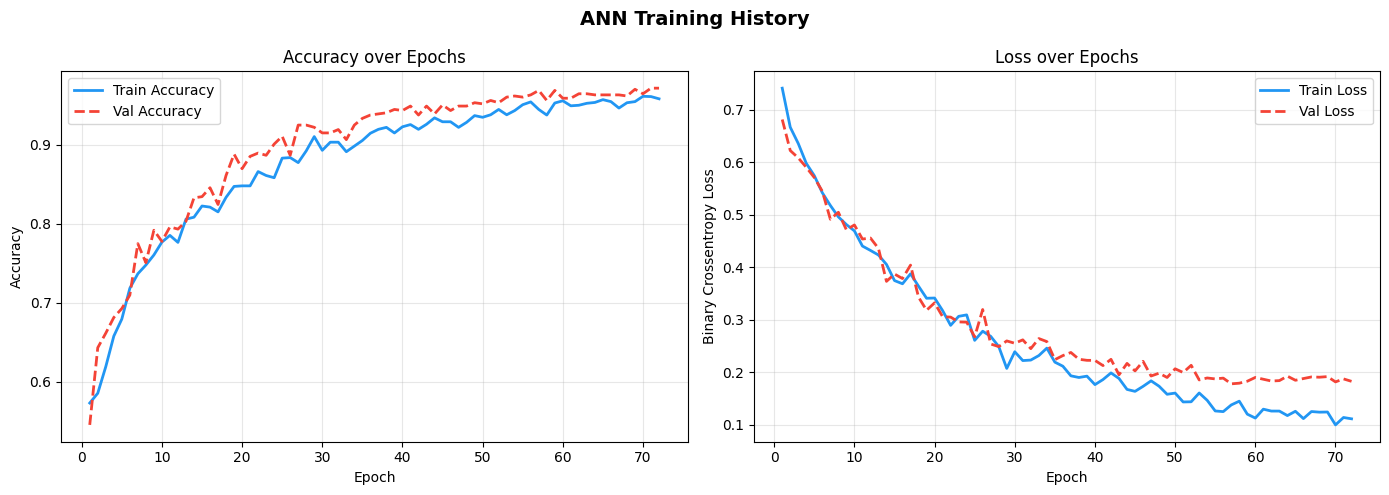

📊 Plot saved → training_history.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ANN Training History', fontsize=14, fontweight='bold')
epochs_ran = range(1, len(history.history['loss']) + 1)

# Accuracy
axes[0].plot(epochs_ran, history.history['accuracy'],     label='Train Accuracy', color='#2196F3', linewidth=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'], label='Val Accuracy',   color='#F44336', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs_ran, history.history['loss'],     label='Train Loss', color='#2196F3', linewidth=2)
axes[1].plot(epochs_ran, history.history['val_loss'], label='Val Loss',   color='#F44336', linewidth=2, linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Binary Crossentropy Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("\U0001f4ca Plot saved \u2192 training_history.png")

## Section 8 — Model Evaluation on the Test Set

In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\u2500\u2500 Test Set Results \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
print(f"   Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"   Test Loss     : {test_loss:.4f}")

# Predictions: probability → binary label (threshold = 0.5)
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

── Test Set Results ────────────────────────────────
   Test Accuracy : 0.9717  (97.17%)
   Test Loss     : 0.1521


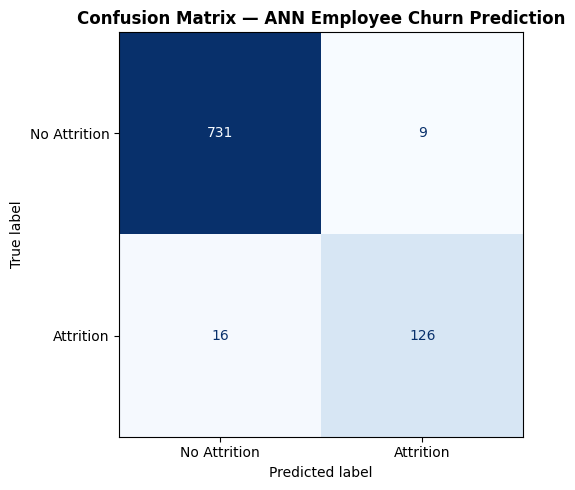

📊 Plot saved → confusion_matrix.png


In [23]:
# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Attrition', 'Attrition'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — ANN Employee Churn Prediction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("\U0001f4ca Plot saved \u2192 confusion_matrix.png")

In [24]:
# Classification Report
# Focus on Recall for class 'Attrition=Yes' — catching actual churners is the key HR goal
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

              precision    recall  f1-score   support

No Attrition       0.98      0.99      0.98       740
   Attrition       0.93      0.89      0.91       142

    accuracy                           0.97       882
   macro avg       0.96      0.94      0.95       882
weighted avg       0.97      0.97      0.97       882



── ROC-AUC Score : 0.9557


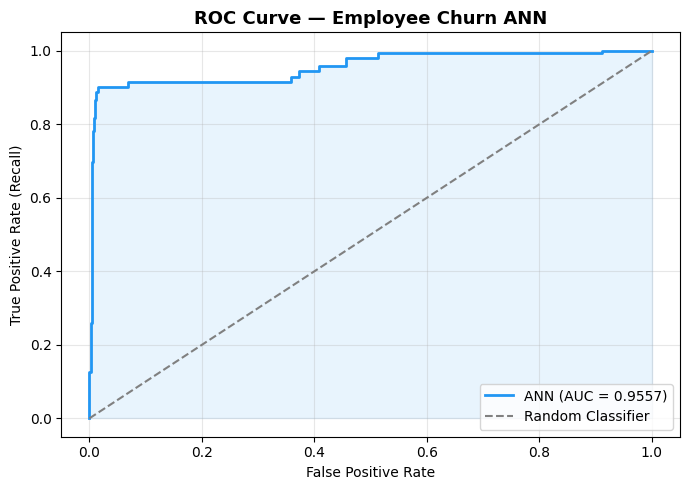

📊 Plot saved → roc_curve.png


In [25]:
# ROC-AUC Score & Curve
from sklearn.metrics import roc_auc_score, roc_curve

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"\u2500\u2500 ROC-AUC Score : {auc_score:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#2196F3', linewidth=2, label=f'ANN (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Employee Churn ANN', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("\U0001f4ca Plot saved \u2192 roc_curve.png")

## Section 9 — Save the Trained Model

In [26]:
# Save in the native Keras format (.keras) — recommended for TF 2.x+
model.save('employee_churn_ann_model.keras')
print("\u2705 Model saved \u2192 employee_churn_ann_model.keras")

# To reload and use later:
# from tensorflow.keras.models import load_model
# loaded_model = load_model('employee_churn_ann_model.keras')
# new_predictions = loaded_model.predict(X_new_scaled)

✅ Model saved → employee_churn_ann_model.keras


## Section 10 — Final Summary Dashboard

In [27]:
print("\n" + "="*60)
print("       FINAL MODEL SUMMARY")
print("="*60)
print(f"  Architecture     : Input({n_features}) \u2192 128 \u2192 Dropout \u2192 64 \u2192 Dropout \u2192 32 \u2192 1")
print(f"  Total Parameters : {model.count_params():,}")
print(f"  Epochs Trained   : {len(history.history['loss'])}")
print(f"  Test Accuracy    : {test_acc*100:.2f}%")
print(f"  Test Loss        : {test_loss:.4f}")
print(f"  ROC-AUC Score    : {auc_score:.4f}")
print("="*60)
print("\n\U0001f4c1 Output files saved:")
print("   \u2022 employee_churn_ann_model.keras")
print("   \u2022 attrition_distribution.png")
print("   \u2022 correlation_heatmap.png")
print("   \u2022 attrition_by_categories.png")
print("   \u2022 training_history.png")
print("   \u2022 confusion_matrix.png")
print("   \u2022 roc_curve.png")


       FINAL MODEL SUMMARY
  Architecture     : Input(38) → 128 → Dropout → 64 → Dropout → 32 → 1
  Total Parameters : 15,361
  Epochs Trained   : 72
  Test Accuracy    : 97.17%
  Test Loss        : 0.1521
  ROC-AUC Score    : 0.9557

📁 Output files saved:
   • employee_churn_ann_model.keras
   • attrition_distribution.png
   • correlation_heatmap.png
   • attrition_by_categories.png
   • training_history.png
   • confusion_matrix.png
   • roc_curve.png
